In [82]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import re
import string
from pyvi import ViUtils
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from joblib import Parallel, delayed
import multiprocessing
import emoji

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")
print("Import thành công")

Import thành công


In [83]:
path = os.path.join('..', 'data', 'raw', 'Product_review_unlabel.xlsx')
df = pd.read_excel(path)

print('Đọc dữ liệu thành công')

Đọc dữ liệu thành công


In [84]:
df = df.dropna(subset=['comment', 'rating'])

In [85]:
def labeling(star):
    if pd.isna(star):
        return None
    elif star <= 2:
        return 0   # Negative
    elif star == 3:
        return 1   # Neutral
    elif star >= 4:
        return 2   # Positive
    else:
        return None

df['label'] = df['rating'].apply(labeling)

In [86]:
df_pos_raw = df[df['label'] == 2]
df_neg_raw = df[df['label'] == 0]
df_neu_raw = df[df['label'] == 1]

data = pd.DataFrame({
    "Nhóm": ["Tích cực", "Tiêu cực", "Trung tính"],
    "Số lượng": [
        df_pos_raw.shape[0],
        df_neg_raw.shape[0],
        df_neu_raw.shape[0]
    ]
})

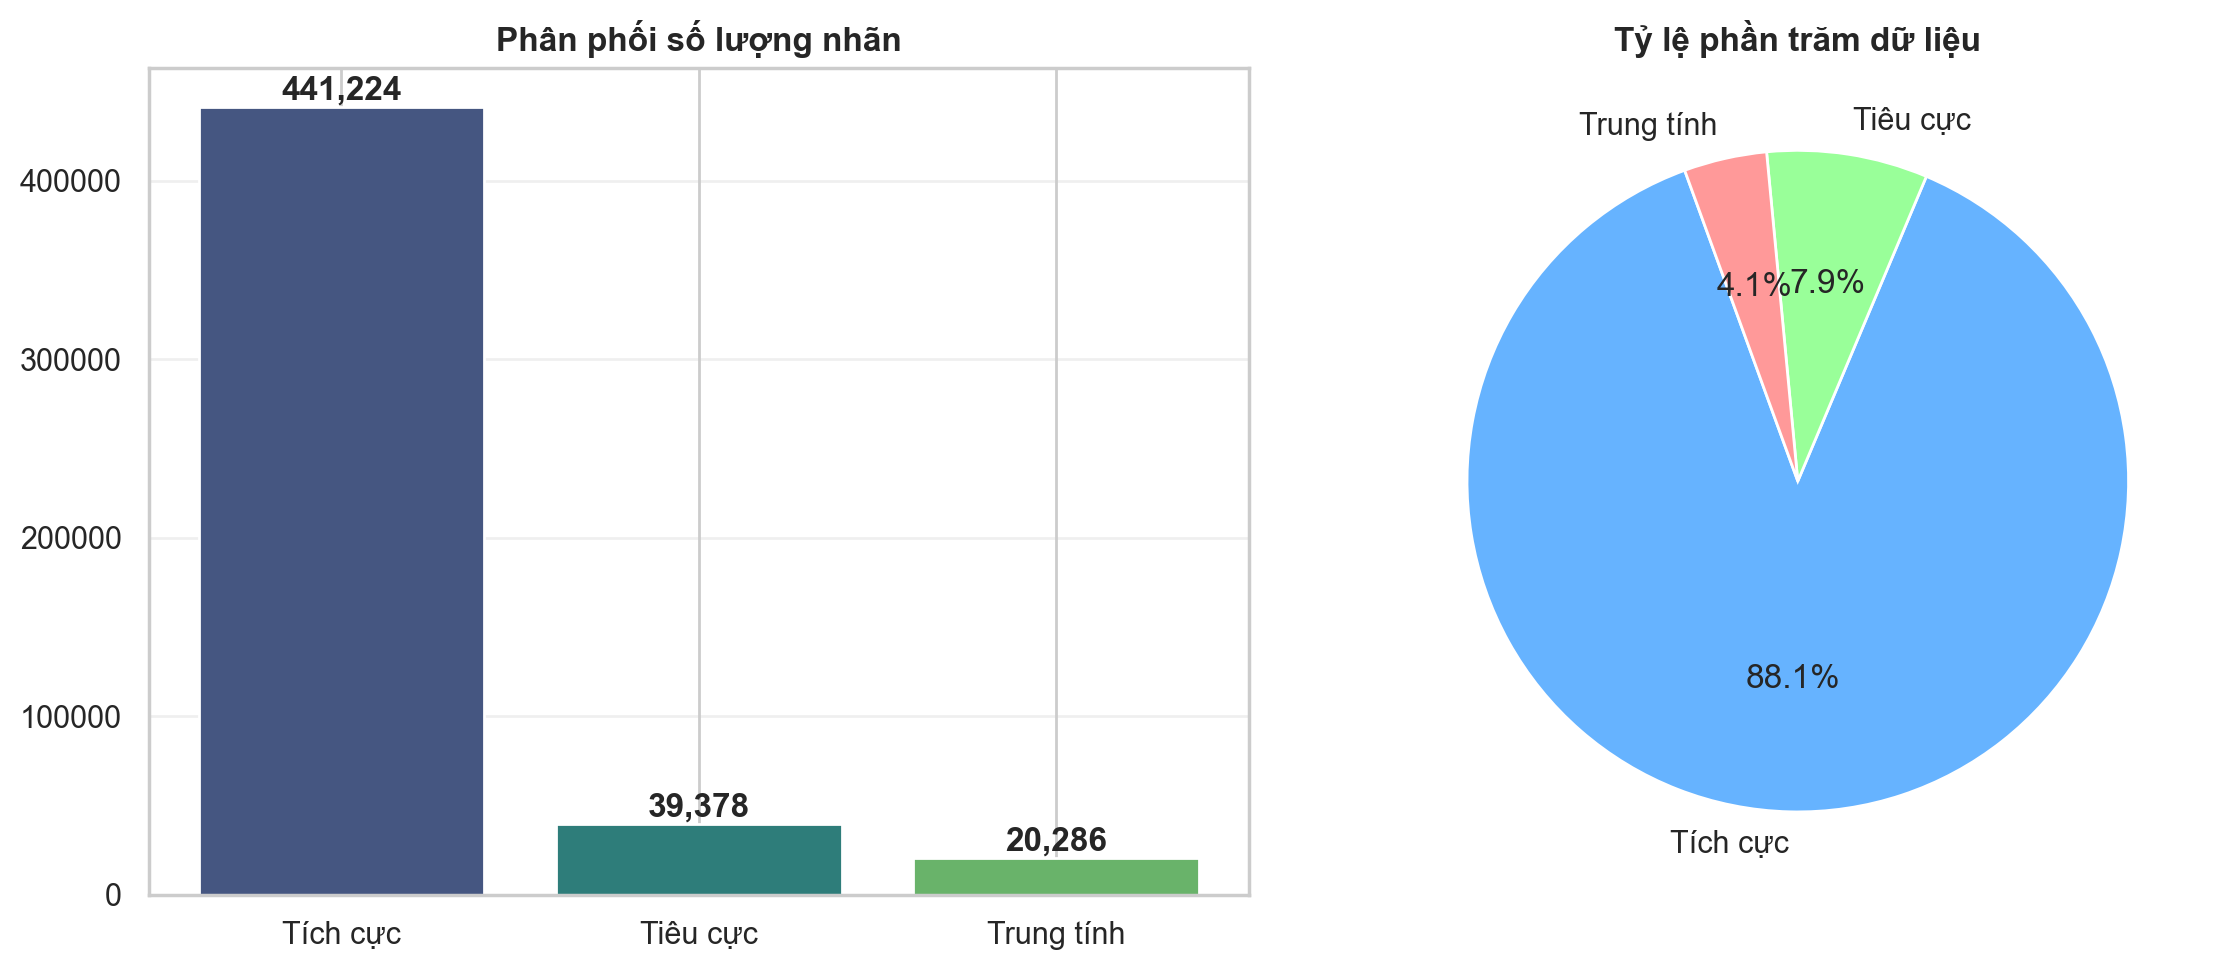

In [87]:
bar_colors = ['#455681', '#2e7d7a', '#69b36a']
pie_colors = ['#66b3ff', '#99ff99', '#ff9999']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar Chart ---
ax[0].bar(data["Nhóm"], data["Số lượng"], color=bar_colors)
ax[0].set_title("Phân phối số lượng nhãn", fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(data["Số lượng"]):
    ax[0].text(i, v + max(data["Số lượng"])*0.01, f"{v:,}", ha='center', fontweight='bold')

# --- Pie Chart ---
ax[1].pie(
    data["Số lượng"],
    labels=data["Nhóm"],
    autopct='%1.1f%%',
    startangle=110,
    colors=pie_colors
)
ax[1].set_title("Tỷ lệ phần trăm dữ liệu", fontweight='bold')

plt.tight_layout()
plt.show()

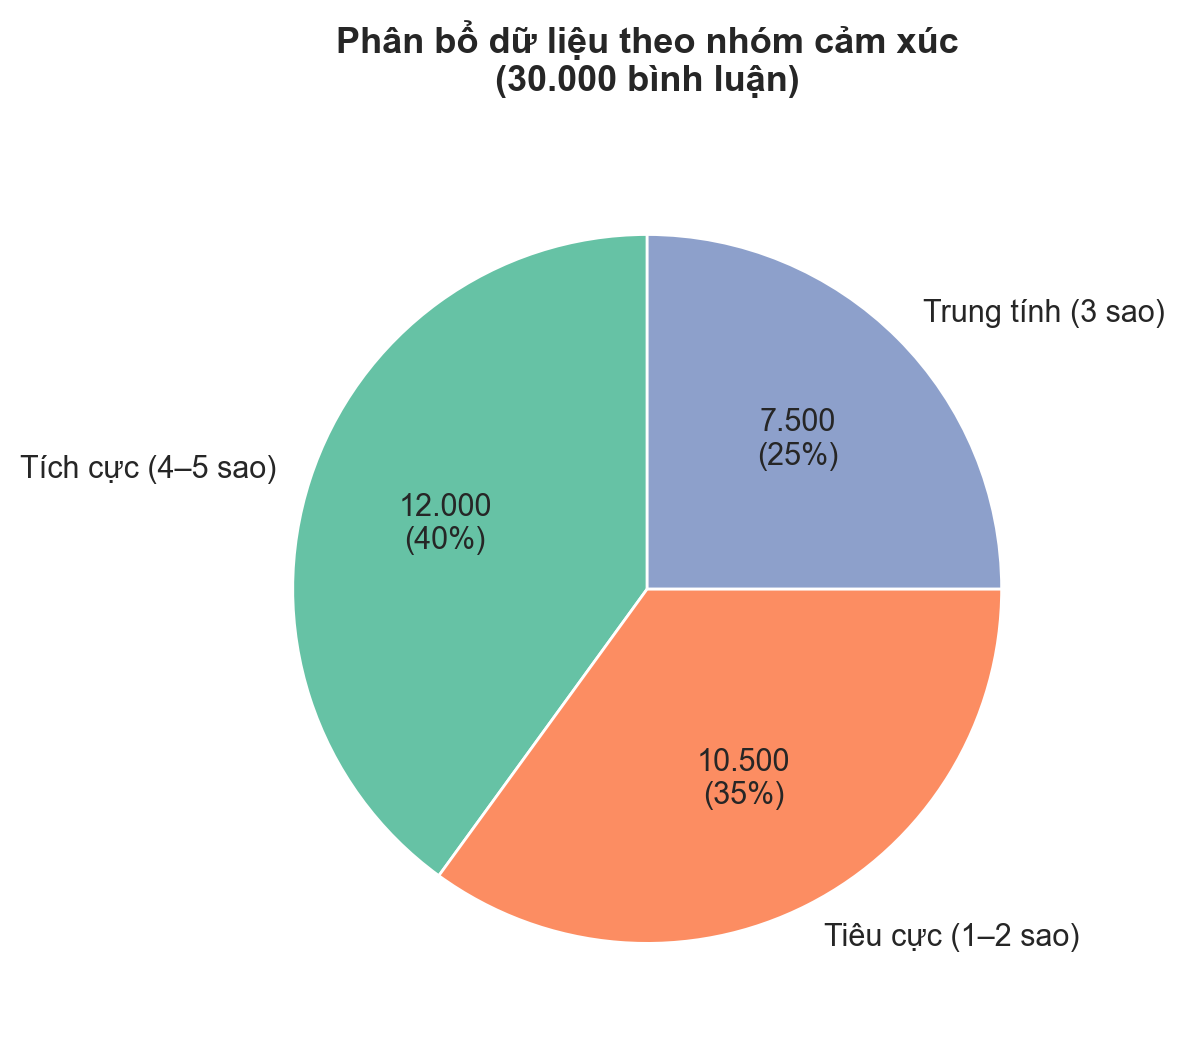

In [88]:
SAMPLE_SIZE = 30000
ratio = {"pos": 0.40, "neg": 0.35, "neu": 0.25}

n_pos = int(SAMPLE_SIZE * ratio["pos"])
n_neg = int(SAMPLE_SIZE * ratio["neg"])
n_neu = int(SAMPLE_SIZE * ratio["neu"])

fig, ax = plt.subplots(figsize=(6, 6))

pie_labels = ['Tích cực (4–5 sao)', 'Tiêu cực (1–2 sao)', 'Trung tính (3 sao)']
pie_sizes = [n_pos, n_neg, n_neu]
pie_colors = ['#66c2a5', '#fc8d62', '#8da0cb']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val:,}\n({pct:.0f}%)'.replace(',', '.')
    return my_autopct

# Vẽ Pie Chart
ax.pie(
    pie_sizes, 
    labels=pie_labels, 
    autopct=make_autopct(pie_sizes),
    startangle=90, 
    colors=pie_colors,
    textprops={'fontsize': 11}
)

ax.set_title("Phân bổ dữ liệu theo nhóm cảm xúc\n(30.000 bình luận)", 
             fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.show()

In [91]:
assert len(df_pos_raw) >= n_pos, "Không đủ mẫu rating 4-5"
assert len(df_neg_raw) >= n_neg, "Không đủ mẫu rating 1-2"
assert len(df_neu_raw) >= n_neu, "Không đủ mẫu rating 3"

df_pos_sample = resample(df_pos_raw, n_samples=n_pos, replace=False, random_state=42)
df_neg_sample = resample(df_neg_raw, n_samples=n_neg, replace=False, random_state=42)
df_neu_sample = resample(df_neu_raw, n_samples=n_neu, replace=False, random_state=42)

df = (
    pd.concat([df_pos_sample, df_neg_sample, df_neu_sample])
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print("Dataset sau sampling:", len(df))

Dataset sau sampling: 30000


In [92]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label']
)

dev_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

Train: (21000, 8)
Dev: (4500, 8)
Test: (4500, 8)


In [93]:
def to_lowercase(text):
    text = str(text).lower()
    return text

In [94]:
def remove_all_tag(sentence):
    """Remove tags added from reading files"""
    return re.sub(r'\n|\t|\r', ' ', sentence)

In [95]:
emoji_dict = {
    # POSITIVE
    "👻": " positive ", "💃": " positive ", "🤙": " positive ", "👍": " positive ",
    "💄": " positive ", "💎": " positive ", "😸": " positive ",
    "🧚": " positive ", "🧡": " positive ", "🐶": " positive ",
    "✨": " positive ", "❣": " positive ", "☀": " positive ",
    "♥": " positive ", "🤩": " positive ", "💌": " positive ",
    "🤣": " positive ", "🖤": " positive ", "🤤": " positive ",
    "❤": " positive ", "😍": " positive ", "😘": " positive ", "😊": " positive ",
    "😁": " positive ", "💖": " positive ",
    "💯": " positive ", "💗": " positive ", "💜": " positive ", "🤗": " positive ",
    "☺": " positive ", "💋": " positive ", "👌": " positive ",
    "😀": " positive ", "😝": " positive ", "😄": " positive ",
    "😎": " positive ", "😆": " positive ", "💚": " positive ",
    "✌": " positive ", "💕": " positive ",
    "😉": " positive ", "😂": " positive ", ":v": " positive ", "=))": " positive ", "😋": " positive ",
    "🙆": " positive ", "🤍": " positive ", "🥰": " positive ",
    ":3": " positive ", "😅": " positive ",
    "😃": " positive ", "😌": " positive ", "💛": " positive ", "🤝": " positive ",
    "🎈": " positive ", "🆗": " positive ", "😻": " positive ", "💙": " positive ",
    "👏": " positive ", ";)": " positive ", "<3": " positive ",
    "🌸": " positive ", "🌺": " positive ", "🌼": " positive ", "🍓": " positive ",
    "💐": " positive ", "💞": " positive ", "💥": " positive ", "💪": " positive ",
    "💰": " positive ", "😇": " positive ", "😛": " positive ", "😜": " positive ",
    "🙃": " positive ", "🤑": " positive ", "🤪": " positive ",

    # NEGATIVE
    "👹": " negative ", "💩": " negative ", "😕": " negative ", "😱": " negative ",
    "😾": " negative ", "🚫": " negative ", "🤬": " negative ",
    "👎": " negative ", "😣": " negative ", ":(": " negative ", "😢": " negative ",
    "😪": " negative ", "😟": " negative ", "😭": " negative ",
    "😨": " negative ", "😖": " negative ", "😡": " negative ", "😠": " negative ",
    "😒": " negative ", "😏": " negative ",
    "😤": " negative ", "😞": " negative ", "😓": " negative ",
    "😐": " negative ", "😫": " negative ", "😥": " negative ",
    "😬": " negative ", "🤔": " negative ", "😑": " negative ",
    "🔥": " negative ", "🙏": " negative ",
    "❌": " negative ", "☹": " negative ", "💀": " negative ",
    "😔": " negative ", "😧": " negative ", "😩": " negative ",
    "😰": " negative ", "😳": " negative ", "🙄": " negative ",
    "🤦": " negative ", "😵": " negative ", "🙁": " negative ",

    # NEUTRAL
    "🤷": " neutral ", "😶": " neutral ", "😴": " neutral ",
    "🙈": " neutral ", "🙉": " neutral ", "🙊": " neutral ",
    "👀": " neutral ", "🤭": " neutral ", "🫠": " neutral ",
    "🫤": " neutral ", "😯": " neutral ", "😲": " neutral ",
    "🤨": " neutral ", "😮": " neutral ",
}

def replace_emoji(text):
    if not isinstance(text, str):
        return ""

    # Replace theo dictionary
    for emo, meaning in emoji_dict.items():
        text = text.replace(emo, meaning)

    # Xóa emoji còn sót
    text = emoji.replace_emoji(text, replace='')

    return text

In [96]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

In [97]:
def load_teencode_dict(path):
    teencode_dict = {}

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            key, value = line.strip().split('\t')
            teencode_dict[key] = value

    return teencode_dict

In [98]:
teencode_dict = load_teencode_dict('../dicts/teencode.txt')

In [99]:
def convert_teencode(text, teencode_dict):
    words = text.split()
    new_words = []

    for word in words:
        if word in teencode_dict:
            new_words.append(teencode_dict[word])
        else:
            new_words.append(word)

    return " ".join(new_words)

In [100]:
def remove_duplicate_letters(text):
    return " ".join(
        re.sub(r'(.)\1+', r'\1', w)
        for w in text.split()
    )

In [101]:
def remove_punctuation(text):
    return re.sub(r'[^\w\sÀ-ỹ]', ' ', text)

In [102]:
def remove_nonsense_words(text):
    vowels = "aeiouyàáạảãăắằẳẵặâấầẩẫậèéẹẻẽêếềểễệìíịỉĩòóọỏõôốồổỗộơớờởỡợùúụủũưứừửữự"

    words = text.split()
    clean_words = []

    for w in words:

        # bỏ từ quá dài
        if len(w) > 20:
            continue

        # kiểm tra tỷ lệ nguyên âm
        vowel_count = sum(1 for c in w if c in vowels)
        if len(w) > 6 and vowel_count / len(w) < 0.2:
            continue

        clean_words.append(w)

    return " ".join(clean_words)

In [103]:

def clean_text(text):
    text = to_lowercase(text)

    text = remove_all_tag(text)
    text = replace_emoji(text)
    text = remove_numbers(text)

    text = remove_duplicate_letters(text)

    # thay dấu câu bằng khoảng trắng
    text = remove_punctuation(text)

    text = convert_teencode(text, teencode_dict)

    # chuẩn hóa khoảng trắng trước khi tokenize
    text = re.sub(r'\s+', ' ', text).strip()

    # bỏ từ rác
    text = remove_nonsense_words(text)

    return text

In [109]:
def clean_dataframe(df, name):
    clean_results = Parallel(
        n_jobs=6, 
        backend="loky", 
        batch_size=200, 
        verbose=0
    )(
        delayed(clean_text)(text) for text in df['comment']
    )
    
    df['clean_review'] = clean_results
    
    # Remove NaN & empty
    before = len(df)
    df = df.dropna(subset=['clean_review'])
    df = df[df['clean_review'].str.strip() != ""].copy()
    after = len(df)
    
    return df

In [110]:
train_df = clean_dataframe(train_df, "Train")
dev_df   = clean_dataframe(dev_df, "Dev")
test_df  = clean_dataframe(test_df, "Test")

In [111]:
display(train_df[['comment', 'clean_review', 'label']].head(5))
display(dev_df[['comment', 'clean_review', 'label']].head(5))
display(test_df[['comment', 'clean_review', 'label']].head(5))

,comment,clean_review,label
7428,Đèn như cc lắp ko quảng cáo lắp xe 50cc về lắp...,đèn như c lắp không quảng cáo lắp xe c về lắp ...,0
8677,Màu sắc:ko đúng\nChất liệu:cx đc\nĐúng với mô ...,màu sắc không đúng chất liệu cũng được đúng vớ...,1
24739,Đây là cái váy,đây là cái váy,1
9012,Kh nh mô tả,không nh mô tả,1
26091,Gió nhẹ ko mát lắm,gió nhẹ không mát lắm,1


,comment,clean_review,label
9068,"Chất liệu:vải\nMàu sắc:xanh\n\nÁo đẹp, vải dày...",chất liệu positive ải màu sắc xanh áo đẹp vải ...,1
21829,Chất liệu kém kh đúng size,chất liệu kém không đúng cỡ,2
23572,Thiếu hàng,thiếu hàng,0
15498,Chất liệu:ko tốt\nMàu sắc:xanh Nước biển\n\nKo...,chất liệu không tốt màu sắc xanh nước biển khô...,0
19394,Đúng với mô tả:mua size XXL gửi size L\nChất l...,đúng với mô tả mua cỡ xuất sắc gửi cỡ l chất l...,0


,comment,clean_review,label
2662,Đúng với mô tả:no\nMàu sắc:trắng\nChất liệu:co...,đúng với mô tả no màu sắc trắng chất liệu coto...,1
7487,Đúng với mô tả:k đúng với mô tả\nMàu sắc:đúng\...,đúng với mô tả không đúng với mô tả màu sắc đú...,1
8859,Chất liệu:ok\nMàu sắc:đẹp\nĐúng với mô tả:đúng...,chất liệu ok màu sắc đẹp đúng với mô tả đúng n...,2
19237,Vải kém chất lượng,vải kém chất lượng,0
10882,"Chất liệu vải mát mịn, giao hàng nhanh, màu đẹ...",chất liệu vải mát mịn giao hàng nhanh màu đẹp ...,2


In [112]:
output_dir = os.path.join('..', 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)

train_df.to_excel(os.path.join(output_dir, 'train.xlsx'), index=False)
dev_df.to_excel(os.path.join(output_dir, 'dev.xlsx'), index=False)
test_df.to_excel(os.path.join(output_dir, 'test.xlsx'), index=False)

print("Đã lưu 3 tập dữ liệu")

Đã lưu 3 tập dữ liệu
